In [1]:
from afisp import WorstSubsetFinder
from afisp import SubgroupPhenotyper
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import afisp.utils as utils
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier

%load_ext autoreload
%autoreload 2

%matplotlib inline

# Load Dataset

In [2]:
df = pd.read_csv("adult_demo_data.csv", header=None)
df.columns = [
    "Age", "WorkClass", "fnlwgt", "Education", "EducationNum",
    "MaritalStatus", "Occupation", "Relationship", "Race", "Gender",
    "CapitalGain", "CapitalLoss", "HoursPerWeek", "NativeCountry", "Income"
]

# binarize features
X = pd.get_dummies(df.iloc[:,:-1], dtype=int, drop_first=True)
X.columns = [''.join(x.split()).replace('-','_').replace('.','_') for x in X.columns]
y = (df.iloc[:, -1] == " >50K").astype(int)

seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

# Train Classification Model

In [3]:
%%time
model = ExplainableBoostingClassifier(random_state=1234, max_bins=10)
model.fit(X_train, y_train)

CPU times: user 1.43 s, sys: 483 ms, total: 1.92 s
Wall time: 4min 55s


,max_bins,10
,random_state,1234
,feature_names,None
,feature_types,None
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015


In [4]:
test_preds = model.predict_proba(X_test)[:, -1]
print("Test AUROC = {}".format(roc_auc_score(y_test, test_preds)))

Test AUROC = 0.927843313435212


#### AFISP identifies specific subgroups where an AI/ML model underperforms. This requires the user to provide as input a trained AI model, the per-sample losses on a test dataset, and features relevant for defining patient characteristics or data acquisition parameters

# Collect AFISP inputs

In [5]:
# we will search for patient subgroups defined with respect to Race, Gender, and Age
subgroup_features = [c for c in X_test.columns 
                     if 'Race' in c or 'Gender' in c or 'Age' in c]
print(subgroup_features)
subgroup_feature_data = X_test[subgroup_features].copy()
# (torch-free hinge AUROC surrogate; equivalent to torch_roc_auc_surrogate(..., 'hinge'))
hinge_auc_loss = utils.roc_auc_surrogate(y_test.to_numpy(), test_preds, 'hinge').mean(axis=0) * 0.5
test_loss = hinge_auc_loss

['Age', 'Race_Asian_Pac_Islander', 'Race_Black', 'Race_Other', 'Race_White', 'Gender_Male']


# Step 1: Finding the worst-performing data subset of the test set

In [6]:
%%time
# Instantiate a WorstSubsetFinder object
from interpret.glassbox import ExplainableBoostingRegressor
# seed the conditional-loss model so the worst-subset step is reproducible
stability_analysis = WorstSubsetFinder(cv=10, verbose=True, eps=1e-5,
                                       subset_fractions=np.arange(0.05, 1, 0.05),
                                       conditional_loss_model=ExplainableBoostingRegressor(random_state=1))
# Fit it using the subgroup feature data, and the per-sample losses
sa_risks = stability_analysis.fit(subgroup_feature_data.values, test_loss)

k = 0


k = 1


k = 2


k = 3


k = 4


k = 5


k = 6


k = 7


k = 8


k = 9


CPU times: user 671 ms, sys: 69.5 ms, total: 741 ms
Wall time: 13.5 s


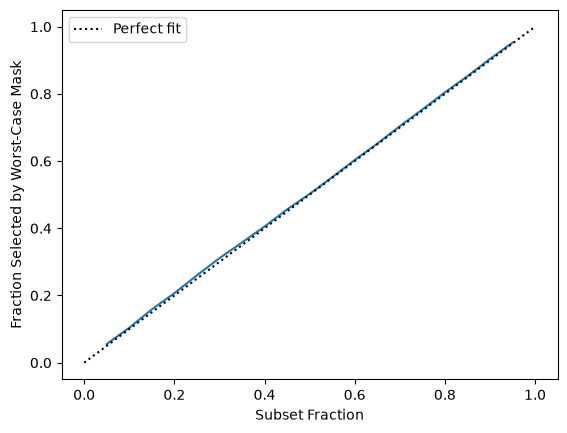

In [7]:
# check that we found subsets of the right size
sa_masks = stability_analysis.subset_masks()
_ = stability_analysis.check_subset_sizes()

### Plot model's performance on worst-case subsets of different sizes

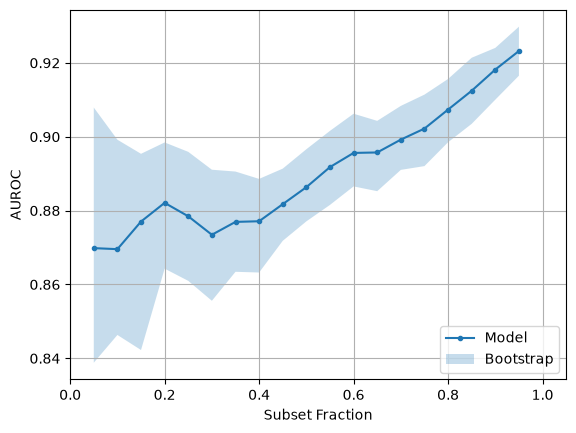

In [8]:
subpop_aucs = []
for m in sa_masks:
    subpop_aucs.append(roc_auc_score(y_test[m], test_preds[m]))
plt.plot(stability_analysis.subset_fractions, subpop_aucs, '.-', label='Model')
# compute bootstrap confidence intervals
bootstrap_cis = np.zeros_like(stability_analysis.confidence_intervals())
for i, alpha in enumerate(stability_analysis.subset_fractions):
    mask = sa_masks[i]
    mean, upper, lower = utils.bootstrap_ci(y_test[mask].values, 
                                            test_preds[mask], 
                                            loss=roc_auc_score)
    bootstrap_cis[i, 0] = lower
    bootstrap_cis[i, 1] = upper

plt.fill_between(stability_analysis.subset_fractions,
                 bootstrap_cis[:, 0], 
                 bootstrap_cis[:, 1], 
                 alpha=0.25, 
                 label='Bootstrap')

plt.ylabel('AUROC')
plt.xlabel('Subset Fraction')
plt.legend(loc='lower right')
plt.xlim(0, 1.05)
plt.grid()

### Find the subset fraction that produces the largest effect size (difference in average performance inside vs outside the subset)

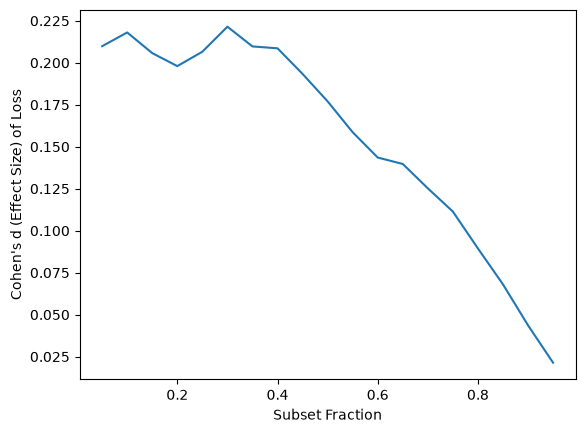

In [9]:
effect_sizes = stability_analysis.compute_effect_sizes(plot=True)

In [10]:
max_ind, max_effect_size = stability_analysis.find_max_effect_size()
print(stability_analysis.subset_fractions[max_ind])

0.3


# Step 2 Subgroup Phenotyping: Finding subgroup phenotypes present in the worst performing subset

In [11]:
# Fit a SubgroupPhenotyper Object
subset_labels = sa_masks[max_ind]*1
sp = SubgroupPhenotyper()
extracted_rules = sp.fit(subgroup_feature_data, subset_labels, test_loss, depth=3, verbose=1, method="SIRUS", random_state=0)

Beginning call to SIRUS. If cv == True this may take a long time.


Finished call to SIRUS
Computing p-values


  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 1021.65it/s]

Effect size filtering


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 1100.21it/s]

### The Subgroup Phenotyper extracts "rules" that define patient subgroups

In [12]:
# Discrete features are encoded as binary indicators
# so Race_Black < 1 means the patient is not black, and Gender_Male >= 1 means the patient is Male
# The first rule would read "Patients 37 or older, who are not Black, and are Male"
sp.generate_subgroup_table(y_test.values, test_preds, loss_fn=roc_auc_score)

,Phenotype,Performance,N,Lower,Upper
2,Age >= 37 & Race_White >= 1 & Gender_Male >= 1,0.875972,2119,0.862044,0.890103
1,Age >= 37 & Race_Black < 1 & Gender_Male >= 1,0.878152,2223,0.864392,0.893112
3,Age >= 37 & Gender_Male >= 1,0.881518,2369,0.870970,0.893676
0,Age >= 26,0.909471,5217,0.902036,0.917255


In [13]:
# The SkopeRules-based DecisionList method is an alternative to SIRUS (no R required for either)
sp.fit(subgroup_feature_data, subset_labels, test_loss, method="DecisionList", depth=3)
sp.generate_subgroup_table(y_test.values, test_preds, loss_fn=roc_auc_score)

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 1082.25it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1176.46it/s]

,Phenotype,Performance,N,Lower,Upper
0,Age <= 65.5 and Age > 38.5 and Gender_Male > 0.5,0.87437,1973,0.857561,0.888279
1,Age > 36.5 and Gender_Male > 0.5,0.88222,2369,0.868608,0.894448
